<a href="https://colab.research.google.com/github/mehmetyilmazreal/PredictingInstrumentSounds/blob/main/sound.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import time
import cv2


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/music_dataset V1"
instruments = ["Acoustic_Guitar", "Drum_set", "Piano", "Violin"]

for instrument in instruments:
    instrument_path = os.path.join(dataset_path, instrument)
    files = os.listdir(instrument_path)
    print(f"{instrument}: {len(files)} dosya")


Acoustic_Guitar: 3744 dosya
Drum_set: 3738 dosya
Piano: 575 dosya
Violin: 648 dosya


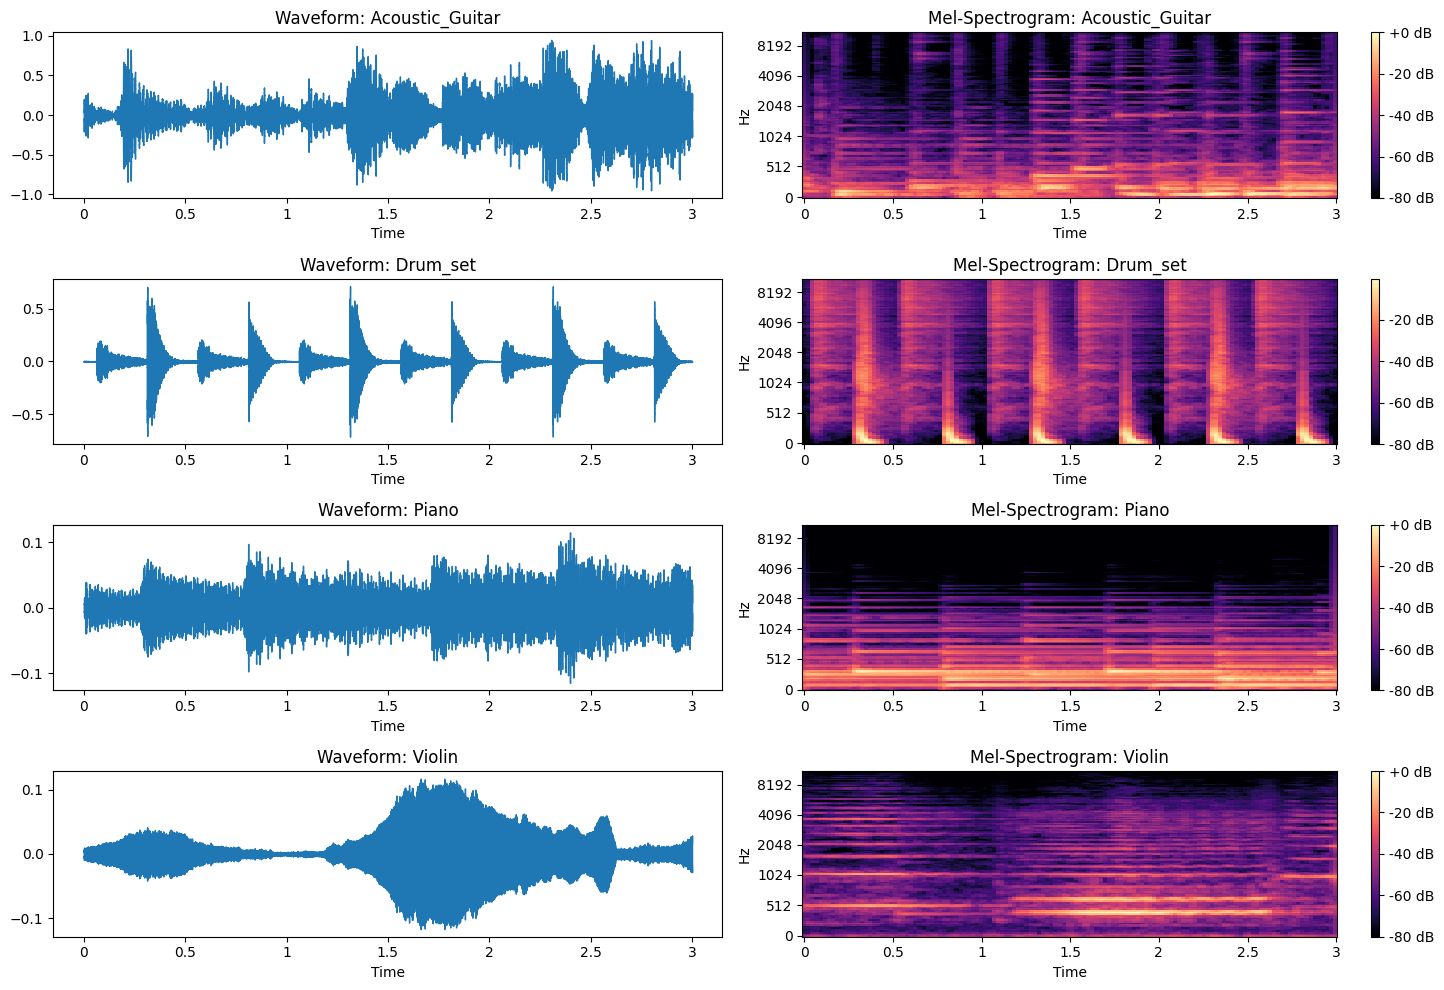

In [ ]:
dataset_path = "/content/drive/MyDrive/music_dataset V1"
instruments = ["Acoustic_Guitar", "Drum_set", "Piano", "Violin"]

# Her sınıftan bir dosya seçip dalga formu ve spektrogram görselleştireceğiz
plt.figure(figsize=(15, 10))

for i, instrument in enumerate(instruments):
    instrument_path = os.path.join(dataset_path, instrument)
    file = next(f for f in os.listdir(instrument_path) if f.endswith(".wav"))
    file_path = os.path.join(instrument_path, file)

    # WAV dosyasını yükle
    signal, sr = librosa.load(file_path, sr=22050)

    # Dalga formunu çiz
    plt.subplot(4, 2, 2*i + 1)
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Waveform: {instrument}")

    # Mel-Spectrogram görselleştirme
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    plt.subplot(4, 2, 2*i + 2)
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Mel-Spectrogram: {instrument}")

plt.tight_layout()
plt.show()


In [ ]:
X, y = [], []

for instrument in instruments:
    instrument_path = os.path.join(dataset_path, instrument)

    for file in os.listdir(instrument_path):
        if file.endswith(".wav"):
            file_path = os.path.join(instrument_path, file)

            # WAV dosyasını yükleme
            signal, sr = librosa.load(file_path, sr=22050)

            # Özellikleri çıkarma
            mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
            mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr)
            chroma = librosa.feature.chroma_stft(y=signal, sr=sr)

            # Ortalama alma
            mfcc_mean = np.mean(mfcc.T, axis=0)
            mel_mean = np.mean(mel_spec.T, axis=0)
            chroma_mean = np.mean(chroma.T, axis=0)

            # Birleştir
            features = np.hstack([mfcc_mean, mel_mean, chroma_mean])

            X.append(features)
            y.append(instrument)

            # Çıktıyı ekrana yazdır
            print(f"🎵 Enstrüman: {instrument}")
            print(f"📌 Dosya: {file}")
            print(f"🔹 Özellik Vektörü ({len(features)} boyutlu):\n{features}\n")
            print("=" * 80)


Görüntülenen çıkış son 5000 satıra kısaltıldı.
  5.3474482e-04  1.0256105e-03  1.5044250e-02  5.3233224e-01
  2.2142661e-01  3.4278892e-03  7.3161609e-03  1.7355858e-01
  3.1767565e-01  2.1194454e-02  6.8252248e-04  8.4762182e-03
  2.0770489e-01  2.0479615e-01  1.6804808e-01  3.2396922e-01
  6.1064392e-02  9.5237801e-03  9.5748581e-02  8.4468311e-01
  1.2157257e-01  1.7240579e-01  3.5582032e-02  4.8250746e-02
  6.6922354e-03  8.7782319e-05  8.2769875e-05  5.1839948e-03
  3.2100771e-03  2.4225805e-03  2.2955446e-03  8.0038655e-05
  1.3960569e-04  8.5151689e-03  2.6218550e-02  2.5413574e-03
  6.4542488e-05  4.2629283e-04  6.1687734e-02  1.1243555e-01
  2.1369457e-02  1.5294699e-02  1.0875091e-02  5.1537519e-03
  1.5794375e-03  3.2245412e-02  1.1056569e-02  1.1292090e-02
  3.3004389e-03  3.2299531e-03  5.2531023e-04  2.1950883e-04
  6.2149746e-05  7.4950000e-03  1.0853128e-02  5.1670950e-03
  8.9110471e-03  1.2558209e-03  3.0741861e-04  1.8953838e-03
  4.0114008e-02  3.4007952e-02  1.3154

/usr/local/lib/python3.11/dist-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


🎵 Enstrüman: Violin
📌 Dosya: 613.wav
🔹 Özellik Vektörü (153 boyutlu):
[-2.51797745e+02  7.45186005e+01 -7.25875320e+01  2.33535500e+01
 -2.35892963e+01 -1.20936785e+01 -1.19301872e+01 -1.20677433e+01
 -2.24254932e+01 -3.85204101e+00  1.15551157e+01  2.66325970e+01
  1.04812927e+01  1.00458160e-01  1.03898346e-02  3.74864019e-03
  1.81212951e-03  9.41257109e-04  9.74447001e-04  1.18177419e-03
  1.14372058e-03  3.31126899e-03  8.17427412e-02  1.10051192e-01
  4.01563793e-02  5.90820089e-02  2.81668329e+00  3.08702254e+00
  1.35200119e+00  1.98821270e+00  1.10152997e-01  2.71213744e-02
  1.95166677e-01  3.65652233e-01  3.59652817e-01  2.37513041e+00
  3.90687180e+00  6.25385952e+00  2.05396128e+00  3.43504459e-01
  1.05114080e-01  7.66378641e-01  2.86618203e-01  2.25127503e-01
  5.86594343e-02  3.16301703e-01  9.99755040e-02  1.15729924e-02
  2.10566055e-02  2.46334840e-02  4.66402858e-01  9.61889684e-01
  9.55374464e-02  3.07302773e-02  1.07016690e-01  1.66824269e+00
  8.81016135e-01  2.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Label encoding
encoder = LabelEncoder()
y = encoder.fit_transform(y)

X = np.array(X)
y = np.array(y)

# Eğitim (%70), Doğrulama (%15), Test (%15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# One-hot encoding
y_train = to_categorical(y_train, num_classes=len(instruments))
y_val = to_categorical(y_val, num_classes=len(instruments))
y_test = to_categorical(y_test, num_classes=len(instruments))

print(f"Eğitim: {len(X_train)}, Doğrulama: {len(X_val)}, Test: {len(X_test)}")


Eğitim: 6093, Doğrulama: 1306, Test: 1306


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, Dropout

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    LSTM(64, return_sequences=True),
    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(len(instruments), activation='softmax')  # Çıkış katmanı
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 151, 64)             │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 75, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 75, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 73, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 36, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 36, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 36, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,812 (436.77 KB)

 Trainable params: 111,812 (436.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

start_time = time.time()

history = model.fit(
    X_train.reshape(-1, X.shape[1], 1), y_train,
    validation_data=(X_val.reshape(-1, X.shape[1], 1), y_val),
    epochs=50,
    batch_size=8
)

end_time = time.time()
print(f"⏳ Eğitim Süresi: {end_time - start_time:.2f} saniye")


Epoch 1/50
762/762 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.8366 - loss: 0.4698 - val_accuracy: 0.9632 - val_loss: 0.1273
Epoch 2/50
762/762 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.9309 - loss: 0.1843 - val_accuracy: 0.9479 - val_loss: 0.1482
Epoch 3/50
762/762 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - accuracy: 0.9538 - loss: 0.1231 - val_accuracy: 0.9709 - val_loss: 0.0872
Epoch 4/50
762/762 ━━━━━━━━━━━━━━━━━━━━ 71s 48ms/step - accuracy: 0.9600 - loss: 0.1096 - val_accuracy: 0.9793 - val_loss: 0.0621
Epoch 5/50
762/762 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9675 - loss: 0.0942 - val_accuracy: 0.9786 - val_loss: 0.0583
Epoch 6/50
762/762 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9596 - loss: 0.1070 - val_accuracy: 0.9809 - val_loss: 0.0541
Epoch 7/50
762/762 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.9715 - loss: 0.0863 - val_accuracy: 0.9625 - val_loss: 0.1195
Epoch 8/50
762/762 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.9569 - loss: 0.1114 - 

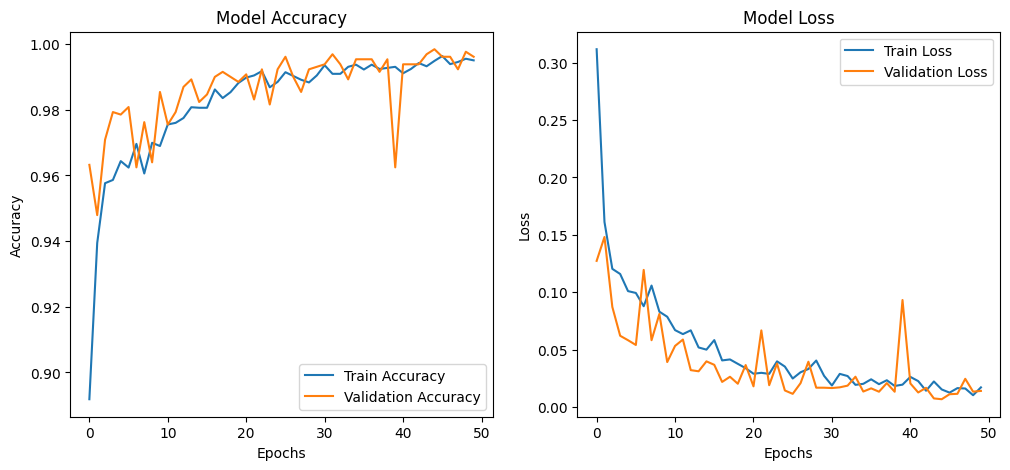

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy Grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step


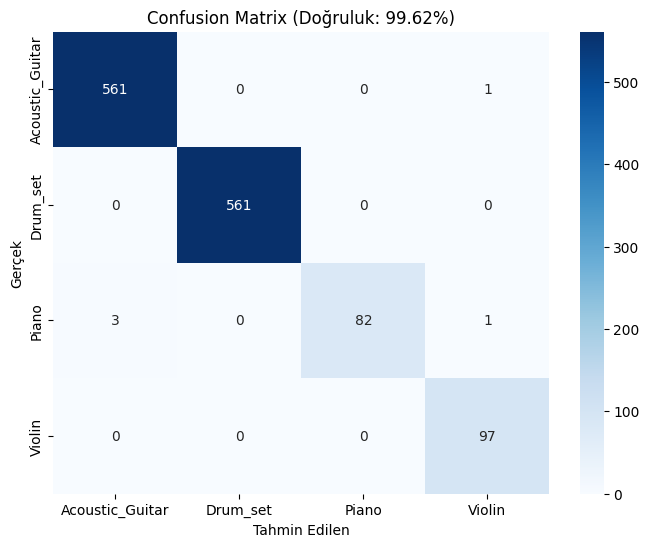

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# Modelin tahminlerini yap
y_pred = model.predict(X_test.reshape(-1, X.shape[1], 1))
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion matrix hesaplama
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Doğruluk oranını hesaplama
accuracy = accuracy_score(y_true_classes, y_pred_classes)

# Confusion Matrix görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=instruments, yticklabels=instruments)
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title(f"Confusion Matrix (Doğruluk: {accuracy * 100:.2f}%)")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Detaylı sınıflandırma raporu
report = classification_report(y_true_classes, y_pred_classes, target_names=instruments)
print("Sınıflandırma Raporu:")
print(report)


Sınıflandırma Raporu:
                 precision    recall  f1-score   support

Acoustic_Guitar       0.99      1.00      1.00       562
       Drum_set       1.00      1.00      1.00       561
          Piano       1.00      0.95      0.98        86
         Violin       0.98      1.00      0.99        97

       accuracy                           1.00      1306
      macro avg       0.99      0.99      0.99      1306
   weighted avg       1.00      1.00      1.00      1306



41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
T1 Skor Tablosu (Classification Report):
                 precision    recall  f1-score      support
Acoustic_Guitar   0.994681  0.998221  0.996448   562.000000
Drum_set          1.000000  1.000000  1.000000   561.000000
Piano             1.000000  0.953488  0.976190    86.000000
Violin            0.979798  1.000000  0.989796    97.000000
accuracy          0.996172  0.996172  0.996172     0.996172
macro avg         0.993620  0.987927  0.990608  1306.000000
weighted avg      0.996211  0.996172  0.996146  1306.000000


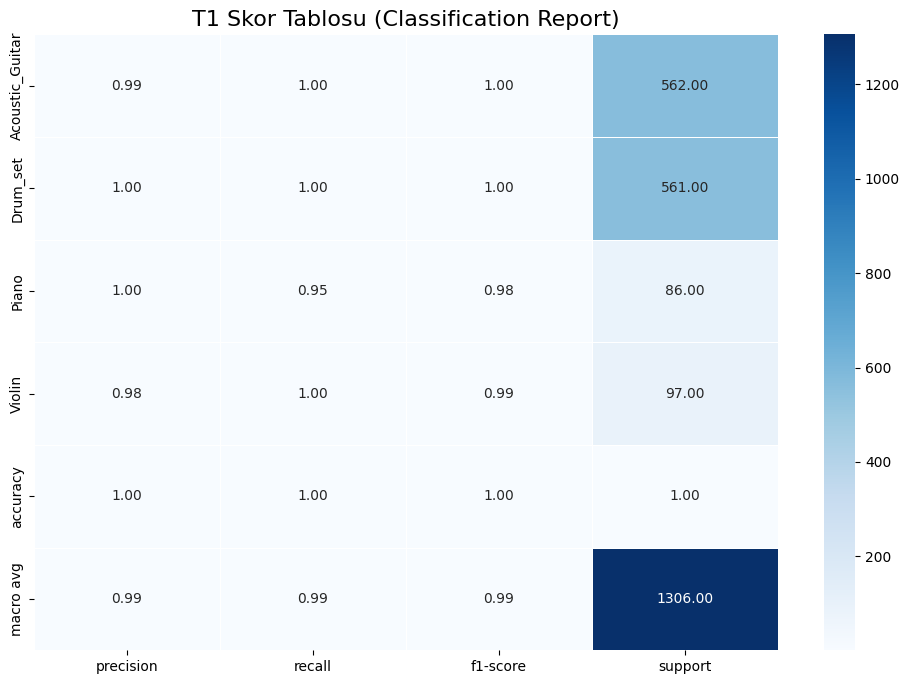

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Modelin tahminlerini yap
y_pred = model.predict(X_test.reshape(-1, X.shape[1], 1))
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Sınıflandırma raporunu al
report = classification_report(y_true_classes, y_pred_classes, target_names=instruments, output_dict=True)

# Raporu DataFrame formatında düzenle
report_df = pd.DataFrame(report).transpose()

# Skor tablosunu yazdır
print("T1 Skor Tablosu (Classification Report):")
print(report_df)

# İsterseniz raporu görsel olarak kaydedebilirsiniz
plt.figure(figsize=(12, 8))
sns.heatmap(report_df.iloc[:-1, :].astype(float), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('T1 Skor Tablosu (Classification Report)', fontsize=16)
plt.show()


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
F1-Skor Tablosu:
        Instrument  F1-Score
0  Acoustic_Guitar  0.996448
1         Drum_set  1.000000
2            Piano  0.976190
3           Violin  0.989796
4          average  0.996172


<ipython-input-18-e8ff623c9ab9>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Instrument", y="F1-Score", data=f1_df, palette="Blues_d")


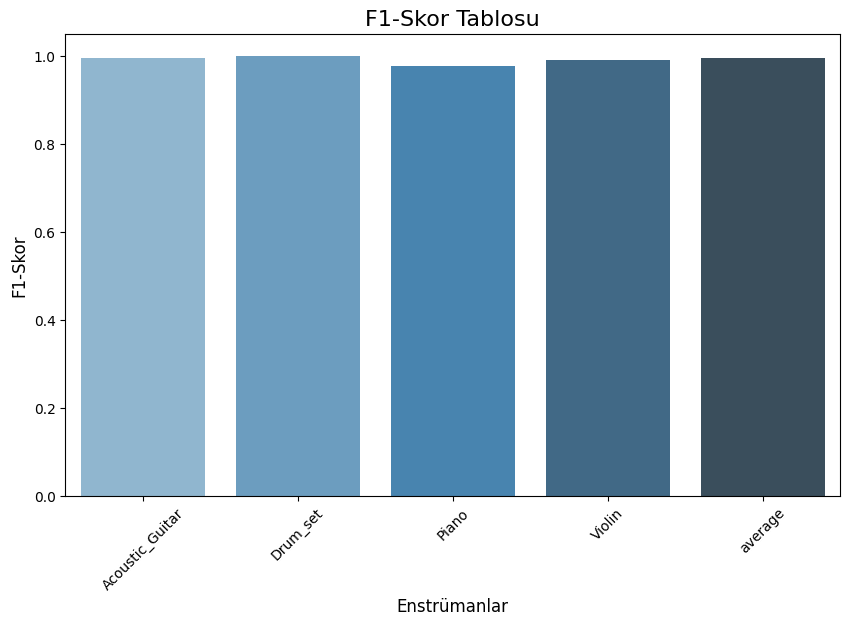

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Modelin tahminlerini yap
y_pred = model.predict(X_test.reshape(-1, X.shape[1], 1))
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Sınıflandırma raporunu al (F1-Skor dahil)
report = classification_report(y_true_classes, y_pred_classes, target_names=instruments, output_dict=True)

# Sadece F1-Skoru al ve DataFrame formatında düzenle
f1_scores = {instrument: report[instrument]['f1-score'] for instrument in instruments}
f1_scores['average'] = report['accuracy']  # Genel doğruluk F1 Skoru olarak eklenebilir

f1_df = pd.DataFrame(list(f1_scores.items()), columns=["Instrument", "F1-Score"])

# F1-Skor tablosunu yazdır
print("F1-Skor Tablosu:")
print(f1_df)

# F1-Skorları görselleştirme
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x="Instrument", y="F1-Score", data=f1_df, palette="Blues_d")
plt.title("F1-Skor Tablosu", fontsize=16)
plt.xlabel("Enstrümanlar", fontsize=12)
plt.ylabel("F1-Skor", fontsize=12)
plt.xticks(rotation=45)
plt.show()


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


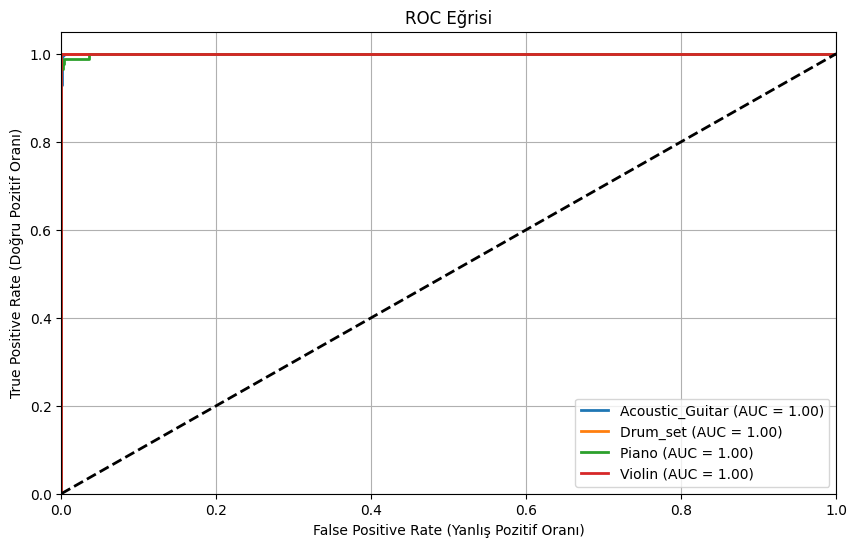

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Sınıf sayısını belirle
n_classes = len(instruments)

# Gerçek değerleri binarize et (One-vs-All için)
y_test_binarized = label_binarize(y_test, classes=np.arange(n_classes))
y_pred_probs = model.predict(X_test.reshape(-1, X.shape[1], 1))  # Tahmin edilen olasılıklar

# ROC eğrisi için çizim
plt.figure(figsize=(10, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f"{instruments[i]} (AUC = {roc_auc:.2f})")

# Referans çizgisi (Random Guess)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Grafik özellikleri
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (Yanlış Pozitif Oranı)")
plt.ylabel("True Positive Rate (Doğru Pozitif Oranı)")
plt.title("ROC Eğrisi")
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Sınıf sayısını belirle
n_classes = len(instruments)

# Gerçek değerleri binarize et (One-vs-All için)
y_test_binarized = label_binarize(y_test, classes=np.arange(n_classes))
y_pred_probs = model.predict(X_test.reshape(-1, X.shape[1], 1))  # Tahmin edilen olasılıklar

# Precision-Recall eğrisini çiz
plt.figure(figsize=(10, 6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_pred_probs[:, i])

    plt.plot(recall, precision, lw=2, label=f"{instruments[i]}")

# Grafik özellikleri
plt.xlabel("Recall (Duyarlılık)")
plt.ylabel("Precision (Kesinlik)")
plt.title("Precision-Recall Eğrisi")
plt.legend(loc="lower left")
plt.grid()
plt.show()


NameError: name 'instruments' is not defined

In [ ]:
import joblib

# Google Drive'da bir yol belirleyin
drive_path = '/content/drive/MyDrive/music_genre_model.joblib'

# Modeli kaydetme
joblib.dump(model, drive_path)
print(f"Model başarıyla {drive_path} olarak kaydedildi.")


Model başarıyla /content/drive/MyDrive/music_genre_model.joblib olarak kaydedildi.


In [ ]:

# Modeli Google Drive'dan yükleme
loaded_model = joblib.load(drive_path)
print("Model başarıyla Google Drive'dan yüklendi.")


NameError: name 'joblib' is not defined